# 0.1 Pass by usando medidas de aforadores automáticos
A continuación se tratará de extraer el pass by usando los datos de un sonómetro en continuo que
esta en simultaneo con una estación aforadora. El objetivo es relacionar la información de niveles
de ruido cada segundo con las detecciones de pasos y velocidades que entrega la estación aforadora

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
plt.style.use("bmh")
%matplotlib inline

In [2]:
def leq(levels:np.ndarray)->float:
    levels = levels[~np.isnan(levels)]
    l = np.array(levels)
    return 10*np.log10(np.mean(np.power(10,l/10)))

# 0.2 Lectura de datos de la estación aforadora
El rada entrega información de dirección de circulación, velocidad y tipo de vehiculo según longitud
entre las siguientes clases:
* 1:bicis y motos
* 2:turismos
* 3:camión
* 4:camión largo

In [3]:
# df = pd.read_csv("20230203.CSV", sep=";")
# file_path = r"\\192.168.205.117\AAC_Server\TRAFICO\REGISTRO_RADAR_VITORIA_2023\P2_M_GANDHI\20230615.CSV"
file_path = r"\\192.168.205.117\AAC_Server\TRAFICO\REGISTRO_RADAR_VITORIA_2023\P2_M_GANDHI\20230616.CSV"
df = pd.read_csv(file_path, sep=";")
df.head()

,Date,Time,Type,Direction,Speed
0,16/06/23,00:02:06,Type 2,Out,25
1,16/06/23,00:03:38,Type 2,In,19
2,16/06/23,00:05:27,Type 2,Out,51
3,16/06/23,00:06:40,Type 1,Out,73
4,16/06/23,00:07:10,Type 2,In,41


el 95% de las detecciones son de vehiculos tipo turismo, y 3% para camiones

In [4]:
df["datetime"] = pd.to_datetime(df["Date"] + " " + df["Time"], format="%d/%m/%y %H:%M:%S")
# Delay con respecto a sonómetro
# df["datetime"] = df["datetime"] + pd.Timedelta("25S")
df

,Date,Time,Type,Direction,Speed,datetime
0,16/06/23,00:02:06,Type 2,Out,25,2023-06-16 00:02:06
1,16/06/23,00:03:38,Type 2,In,19,2023-06-16 00:03:38
2,16/06/23,00:05:27,Type 2,Out,51,2023-06-16 00:05:27
3,16/06/23,00:06:40,Type 1,Out,73,2023-06-16 00:06:40
4,16/06/23,00:07:10,Type 2,In,41,2023-06-16 00:07:10
...,...,...,...,...,...,...
4173,16/06/23,23:57:17,Type 2,In,33,2023-06-16 23:57:17
4174,16/06/23,23:57:30,Type 2,In,40,2023-06-16 23:57:30
4175,16/06/23,23:58:38,Type 2,In,24,2023-06-16 23:58:38
4176,16/06/23,23:59:19,Type 2,In,40,2023-06-16 23:59:19


In [5]:
df["Type"].value_counts(normalize=True)

Type 2    0.940881
Type 1    0.051699
Type 3    0.006702
Type 4    0.000718
Name: Type, dtype: float64

In [6]:
# printing the max speed and the min speed
print("Max speed: ", df["Speed"].max())
print("Min speed: ", df["Speed"].min())

Max speed:  96
Min speed:  8


c:\Users\GIS2\.conda\envs\inference\lib\site-packages\ipykernel_launcher.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  


<AxesSubplot:xlabel='Speed'>

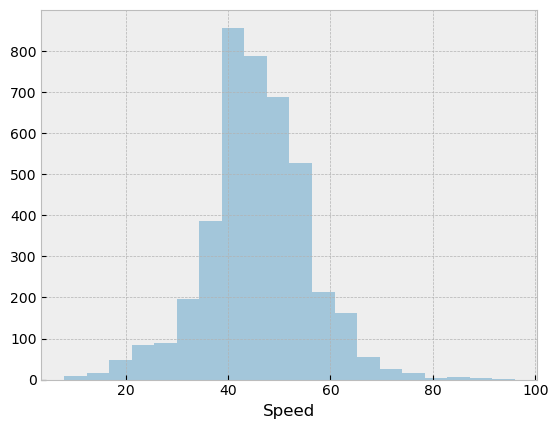

In [7]:
# plot the speed distribution in a histogram plot using seaborn
sns.distplot(df["Speed"], bins=20, kde=False)


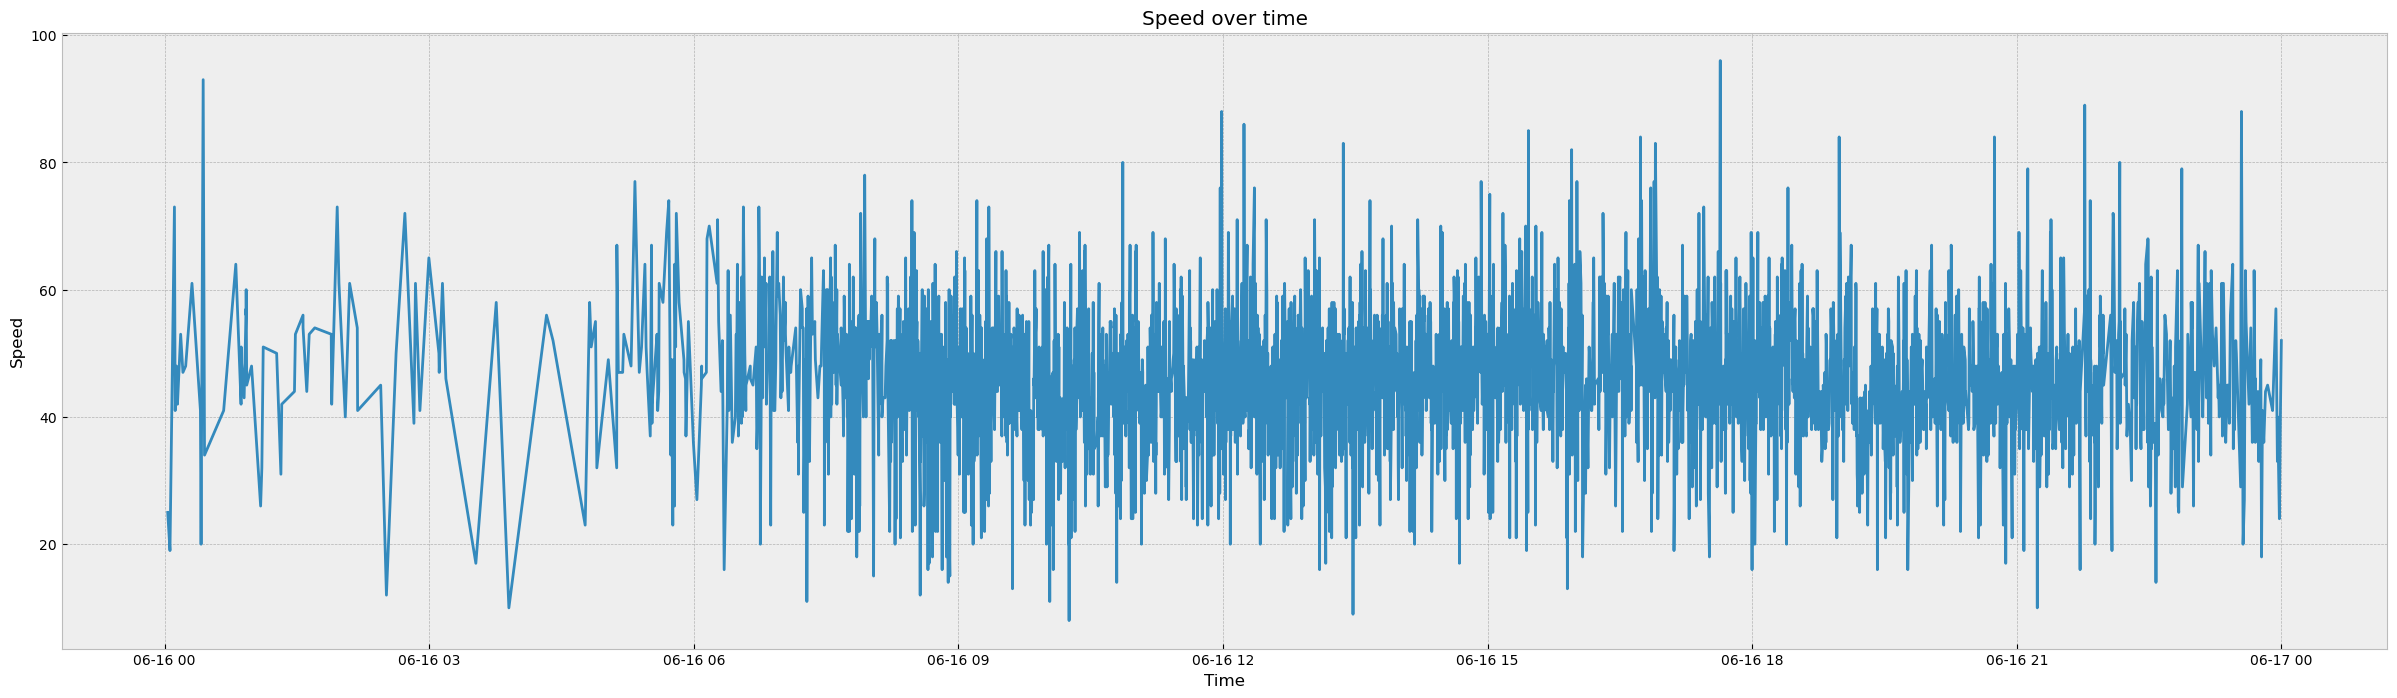

In [8]:
# plotting the speed over time. using speed column as y-axis and time column as x-axis
plt.figure(figsize=(30, 8))

plt.plot(df["datetime"], df["Speed"])

plt.xlabel("Time")
plt.ylabel("Speed")
plt.title("Speed over time")

plt.show()

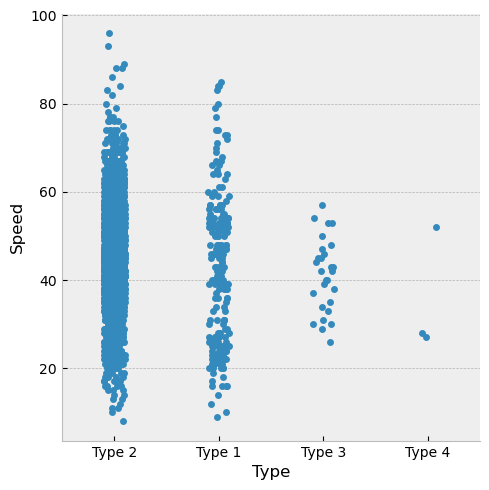

In [9]:
sns.catplot(data=df, x="Type",y="Speed");

#  1 LECTURA DE DATOS NIVELES DE RUIDO

SPL LA

In [7]:
# df_noise = pd.read_csv("Audiomoth2_Tanis_Aguirrebengoa_20230203_spl.csv",parse_dates=["date"])
# df_noise = pd.read_csv("Audiomoth2_Tanis_Aguirrebengoa_20230615_spl.csv", parse_dates=["date"])

noise_file_path = r"E:\AUDIOS_ID\2023\TRÁFICO\Vitoria_Radar\P2_M_GANDHI\Medidas_Audio_MothP2_spl.csv"

df_noise = pd.read_csv(noise_file_path, parse_dates=["date"])

df_noise

,LA,LC,LZ,LAmax,LAmin,filename,date
0,65.82,70.30,70.50,68.72,61.73,20230615_124441.wav,2023-06-15 12:44:41
1,66.60,71.16,71.51,68.43,64.55,20230615_124441.wav,2023-06-15 12:44:42
2,66.89,71.34,71.73,72.43,63.75,20230615_124441.wav,2023-06-15 12:44:43
3,67.24,70.71,70.88,69.92,59.01,20230615_124441.wav,2023-06-15 12:44:44
4,77.16,81.24,81.32,84.34,58.22,20230615_124441.wav,2023-06-15 12:44:45


In [8]:
# this is for the privious one

# df_noise["date"] = df_noise["date"] + pd.Timedelta("1H")

# df_noise

,LA,LC,LZ,LAmax,LAmin,filename,date
0,65.82,70.30,70.50,68.72,61.73,20230615_124441.wav,2023-06-15 13:44:41
1,66.60,71.16,71.51,68.43,64.55,20230615_124441.wav,2023-06-15 13:44:42
2,66.89,71.34,71.73,72.43,63.75,20230615_124441.wav,2023-06-15 13:44:43
3,67.24,70.71,70.88,69.92,59.01,20230615_124441.wav,2023-06-15 13:44:44
4,77.16,81.24,81.32,84.34,58.22,20230615_124441.wav,2023-06-15 13:44:45
...,...,...,...,...,...,...,...
602625,52.51,60.14,60.73,55.99,48.08,20230622_130340.wav,2023-06-22 14:18:35
602626,53.17,61.19,61.66,55.21,51.19,20230622_130340.wav,2023-06-22 14:18:36
602627,54.77,62.17,62.60,55.93,52.78,20230622_130340.wav,2023-06-22 14:18:37
602628,77.93,81.15,81.25,85.00,55.75,20230622_130340.wav,2023-06-22 14:18:38


Inicilamente se usa el campo que contiene la información de los timestamps de las detecciónes para
unir los datos de la estación de aforos con los niveles de ruido. Como la longitud de los datos
de ruido no es igual a la de los datos de los aforos, se realiza una union “izquierda” en donde se
conservan los datos de la tabla izquierda(ruido) y solo se unen los datos de aforo en los campos
coincidentes.

In [9]:
df_join = pd.merge(df_noise, df, left_on="date", right_on="datetime", how="left")
df_join

,LA,LC,LZ,LAmax,LAmin,filename,date,Date,Time,Type,Direction,Speed,datetime
0,65.82,70.30,70.50,68.72,61.73,20230615_124441.wav,2023-06-15 13:44:41,NaN,NaN,NaN,NaN,NaN,NaT
1,66.60,71.16,71.51,68.43,64.55,20230615_124441.wav,2023-06-15 13:44:42,NaN,NaN,NaN,NaN,NaN,NaT
2,66.89,71.34,71.73,72.43,63.75,20230615_124441.wav,2023-06-15 13:44:43,NaN,NaN,NaN,NaN,NaN,NaT
3,67.24,70.71,70.88,69.92,59.01,20230615_124441.wav,2023-06-15 13:44:44,NaN,NaN,NaN,NaN,NaN,NaT
4,77.16,81.24,81.32,84.34,58.22,20230615_124441.wav,2023-06-15 13:44:45,NaN,NaN,NaN,NaN,NaN,NaT
...,...,...,...,...,...,...,...,...,...,...,...,...,...
602651,52.51,60.14,60.73,55.99,48.08,20230622_130340.wav,2023-06-22 14:18:35,NaN,NaN,NaN,NaN,NaN,NaT
602652,53.17,61.19,61.66,55.21,51.19,20230622_130340.wav,2023-06-22 14:18:36,NaN,NaN,NaN,NaN,NaN,NaT
602653,54.77,62.17,62.60,55.93,52.78,20230622_130340.wav,2023-06-22 14:18:37,NaN,NaN,NaN,NaN,NaN,NaT
602654,77.93,81.15,81.25,85.00,55.75,20230622_130340.wav,2023-06-22 14:18:38,NaN,NaN,NaN,NaN,NaN,NaT


Se puede observar en el siguiente gráfico como la detecciones del sistema de aforos concuerdan con
los picos de niveles de ruido en este segmento.

In [10]:
df_join = df_join.set_index("date")
# df_temp = df_join.loc["2023-02-03 23:55:00":"2023-02-03 23:58:00"]

df_join

,LA,LC,LZ,LAmax,LAmin,filename,Date,Time,Type,Direction,Speed,datetime
date,,,,,,,,,,,,
2023-06-15 13:44:41,65.82,70.30,70.50,68.72,61.73,20230615_124441.wav,NaN,NaN,NaN,NaN,NaN,NaT
2023-06-15 13:44:42,66.60,71.16,71.51,68.43,64.55,20230615_124441.wav,NaN,NaN,NaN,NaN,NaN,NaT
2023-06-15 13:44:43,66.89,71.34,71.73,72.43,63.75,20230615_124441.wav,NaN,NaN,NaN,NaN,NaN,NaT
2023-06-15 13:44:44,67.24,70.71,70.88,69.92,59.01,20230615_124441.wav,NaN,NaN,NaN,NaN,NaN,NaT
2023-06-15 13:44:45,77.16,81.24,81.32,84.34,58.22,20230615_124441.wav,NaN,NaN,NaN,NaN,NaN,NaT
...,...,...,...,...,...,...,...,...,...,...,...,...
2023-06-22 14:18:35,52.51,60.14,60.73,55.99,48.08,20230622_130340.wav,NaN,NaN,NaN,NaN,NaN,NaT
2023-06-22 14:18:36,53.17,61.19,61.66,55.21,51.19,20230622_130340.wav,NaN,NaN,NaN,NaN,NaN,NaT
2023-06-22 14:18:37,54.77,62.17,62.60,55.93,52.78,20230622_130340.wav,NaN,NaN,NaN,NaN,NaN,NaT


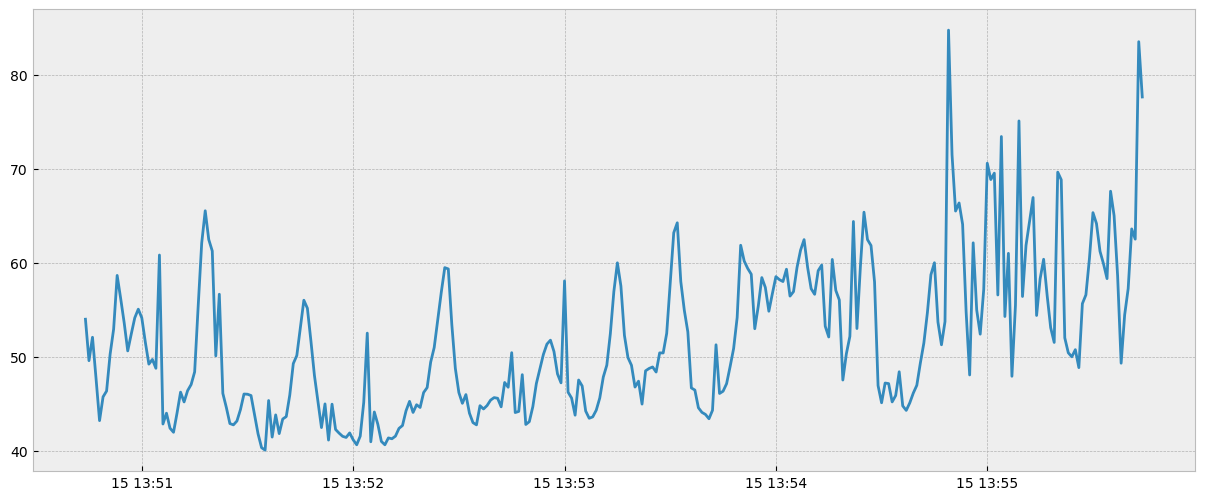

In [11]:
df_temp = df_join.loc["2023-06-15 13:50:44": "2023-06-15 13:55:44"]

levels = df_temp["LA"].values
speed = df_temp["Speed"].values

plt.figure(figsize=(15,6))

plt.plot(df_temp.index, levels);
plt.plot(df_temp.index, speed + 40, "*");

Sonometro

In [10]:
df

,Date,Time,Type,Direction,Speed,datetime
0,16/06/23,00:02:06,Type 2,Out,25,2023-06-16 00:02:06
1,16/06/23,00:03:38,Type 2,In,19,2023-06-16 00:03:38
2,16/06/23,00:05:27,Type 2,Out,51,2023-06-16 00:05:27
3,16/06/23,00:06:40,Type 1,Out,73,2023-06-16 00:06:40
4,16/06/23,00:07:10,Type 2,In,41,2023-06-16 00:07:10
...,...,...,...,...,...,...
4173,16/06/23,23:57:17,Type 2,In,33,2023-06-16 23:57:17
4174,16/06/23,23:57:30,Type 2,In,40,2023-06-16 23:57:30
4175,16/06/23,23:58:38,Type 2,In,24,2023-06-16 23:58:38
4176,16/06/23,23:59:19,Type 2,In,40,2023-06-16 23:59:19


In [17]:
# add 2 min and 5 seconds to the datetime column
# df["datetime"] = df["datetime"] + pd.Timedelta("2M") + pd.Timedelta("5S")
df["datetime"] = df["datetime"] + pd.Timedelta("5S")
df

,Date,Time,Type,Direction,Speed,datetime
0,16/06/23,00:02:06,Type 2,Out,25,2023-06-16 00:04:16
1,16/06/23,00:03:38,Type 2,In,19,2023-06-16 00:05:48
2,16/06/23,00:05:27,Type 2,Out,51,2023-06-16 00:07:37
3,16/06/23,00:06:40,Type 1,Out,73,2023-06-16 00:08:50
4,16/06/23,00:07:10,Type 2,In,41,2023-06-16 00:09:20
...,...,...,...,...,...,...
4173,16/06/23,23:57:17,Type 2,In,33,2023-06-16 23:59:27
4174,16/06/23,23:57:30,Type 2,In,40,2023-06-16 23:59:40
4175,16/06/23,23:58:38,Type 2,In,24,2023-06-17 00:00:48
4176,16/06/23,23:59:19,Type 2,In,40,2023-06-17 00:01:29


In [12]:
noise_file_path = r"E:\AUDIOS_ID\2023\TRÁFICO\Vitoria_Radar\P2_M_GANDHI\LxT_0004545-20230615 125242-LxT_Data.464.xlsx"

# df_noise = pd.read_csv(noise_file_path, parse_dates=["date"])

df_noise = pd.read_excel(noise_file_path, sheet_name='Historia del tiempo')
df_noise.head()
# df_noise['date'] = pd.to_datetime(df['Fecha'])

,Registro #,Tipo de registro,Fecha,Hora,LAeq,LAFmax,LAFmin,OVLD,Marcador,Comments
0,1,correr,2023-06-15 12:52:42,2023-06-15 12:52:42,NaN,NaN,NaN,NaN,NaN,NaN
1,2,NaN,2023-06-15 12:52:42,2023-06-15 12:52:42,53.9,54.8,51.8,No,NaN,NaN
2,3,NaN,2023-06-15 12:52:43,2023-06-15 12:52:43,56.2,56.6,54.6,No,NaN,NaN
3,4,NaN,2023-06-15 12:52:44,2023-06-15 12:52:44,57.7,58.5,56.2,No,NaN,NaN
4,5,NaN,2023-06-15 12:52:45,2023-06-15 12:52:45,61.7,66.2,57.8,No,NaN,NaN


In [13]:
# 	LA	LC	LZ	LAmax	LAmin	filename	date
# 0	65.82	70.30	70.50	68.72	61.73	20230615_124441.wav	2023-06-15 13:44:41
# 1	66.60	71.16	71.51	68.43	64.55	20230615_124441.wav	2023-06-15 13:44:42

In [32]:
# df_noise["Fecha"] = df_noise["Fecha"] + pd.Timedelta("1H")

# df_noise

,Registro #,Tipo de registro,Fecha,Hora,LAeq,LAFmax,LAFmin,OVLD,Marcador,Comments
0,1,correr,2023-06-15 13:52:42,2023-06-15 12:52:42,NaN,NaN,NaN,NaN,NaN,NaN
1,2,NaN,2023-06-15 13:52:42,2023-06-15 12:52:42,53.9,54.8,51.8,No,NaN,NaN
2,3,NaN,2023-06-15 13:52:43,2023-06-15 12:52:43,56.2,56.6,54.6,No,NaN,NaN
3,4,NaN,2023-06-15 13:52:44,2023-06-15 12:52:44,57.7,58.5,56.2,No,NaN,NaN
4,5,NaN,2023-06-15 13:52:45,2023-06-15 12:52:45,61.7,66.2,57.8,No,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
593258,593259,NaN,2023-06-22 10:40:19,2023-06-22 09:40:19,67.6,69.7,65.8,No,NaN,NaN
593259,593260,NaN,2023-06-22 10:40:20,2023-06-22 09:40:20,62.9,65.8,61.6,No,NaN,NaN
593260,593261,NaN,2023-06-22 10:40:21,2023-06-22 09:40:21,60.1,61.8,59.0,No,NaN,NaN
593261,593262,NaN,2023-06-22 10:40:22,2023-06-22 09:40:22,58.5,59.0,58.7,No,NaN,NaN


In [18]:
df_join = pd.merge(df_noise, df, left_on="Fecha", right_on="datetime", how="left")
df_join

,Registro #,Tipo de registro,Fecha,Hora,LAeq,LAFmax,LAFmin,OVLD,Marcador,Comments,Date,Time,Type,Direction,Speed,datetime
0,1,correr,2023-06-15 12:52:42,2023-06-15 12:52:42,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
1,2,NaN,2023-06-15 12:52:42,2023-06-15 12:52:42,53.9,54.8,51.8,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
2,3,NaN,2023-06-15 12:52:43,2023-06-15 12:52:43,56.2,56.6,54.6,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
3,4,NaN,2023-06-15 12:52:44,2023-06-15 12:52:44,57.7,58.5,56.2,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
4,5,NaN,2023-06-15 12:52:45,2023-06-15 12:52:45,61.7,66.2,57.8,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
593284,593259,NaN,2023-06-22 09:40:19,2023-06-22 09:40:19,67.6,69.7,65.8,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
593285,593260,NaN,2023-06-22 09:40:20,2023-06-22 09:40:20,62.9,65.8,61.6,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
593286,593261,NaN,2023-06-22 09:40:21,2023-06-22 09:40:21,60.1,61.8,59.0,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
593287,593262,NaN,2023-06-22 09:40:22,2023-06-22 09:40:22,58.5,59.0,58.7,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT


In [19]:
df_join = df_join.set_index("Fecha")
# df_temp = df_join.loc["2023-02-03 23:55:00":"2023-02-03 23:58:00"]

df_join.head()

,Registro #,Tipo de registro,Hora,LAeq,LAFmax,LAFmin,OVLD,Marcador,Comments,Date,Time,Type,Direction,Speed,datetime
Fecha,,,,,,,,,,,,,,,
2023-06-15 12:52:42,1,correr,2023-06-15 12:52:42,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
2023-06-15 12:52:42,2,NaN,2023-06-15 12:52:42,53.9,54.8,51.8,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
2023-06-15 12:52:43,3,NaN,2023-06-15 12:52:43,56.2,56.6,54.6,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
2023-06-15 12:52:44,4,NaN,2023-06-15 12:52:44,57.7,58.5,56.2,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
2023-06-15 12:52:45,5,NaN,2023-06-15 12:52:45,61.7,66.2,57.8,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT


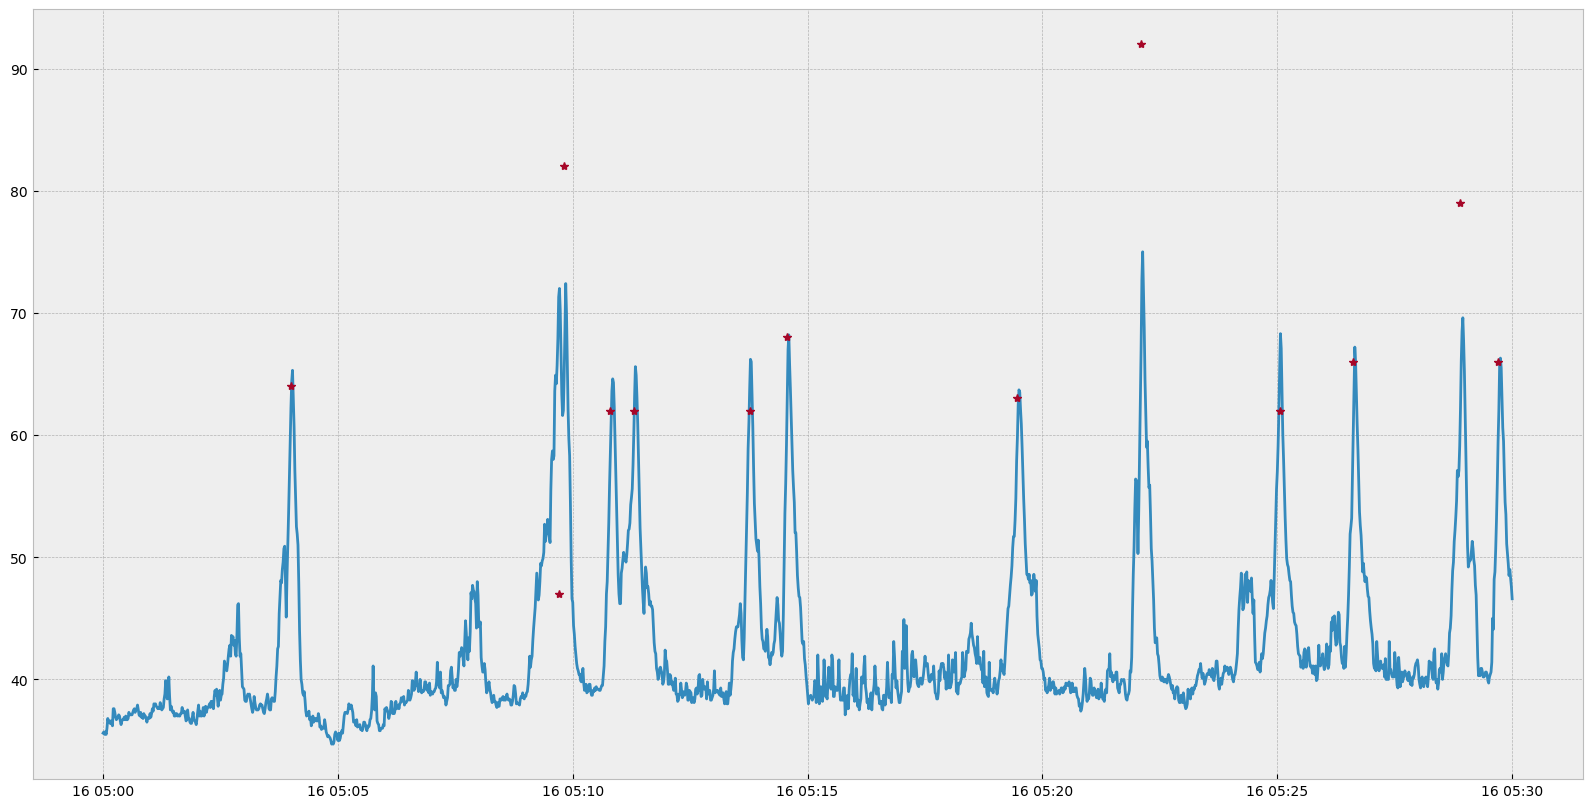

In [20]:
df_temp = df_join.loc["2023-06-16 05:00:00": "2023-06-16 05:30:00"]

levels = df_temp["LAeq"].values

# make log 10 of all speed values
speed = df_temp["Speed"].values
speed_log_scaled = 10 * np.log10(speed + 1)

plt.figure(figsize=(20,10))
plt.plot(df_temp.index, levels);
plt.plot(df_temp.index, speed + 15, "*");

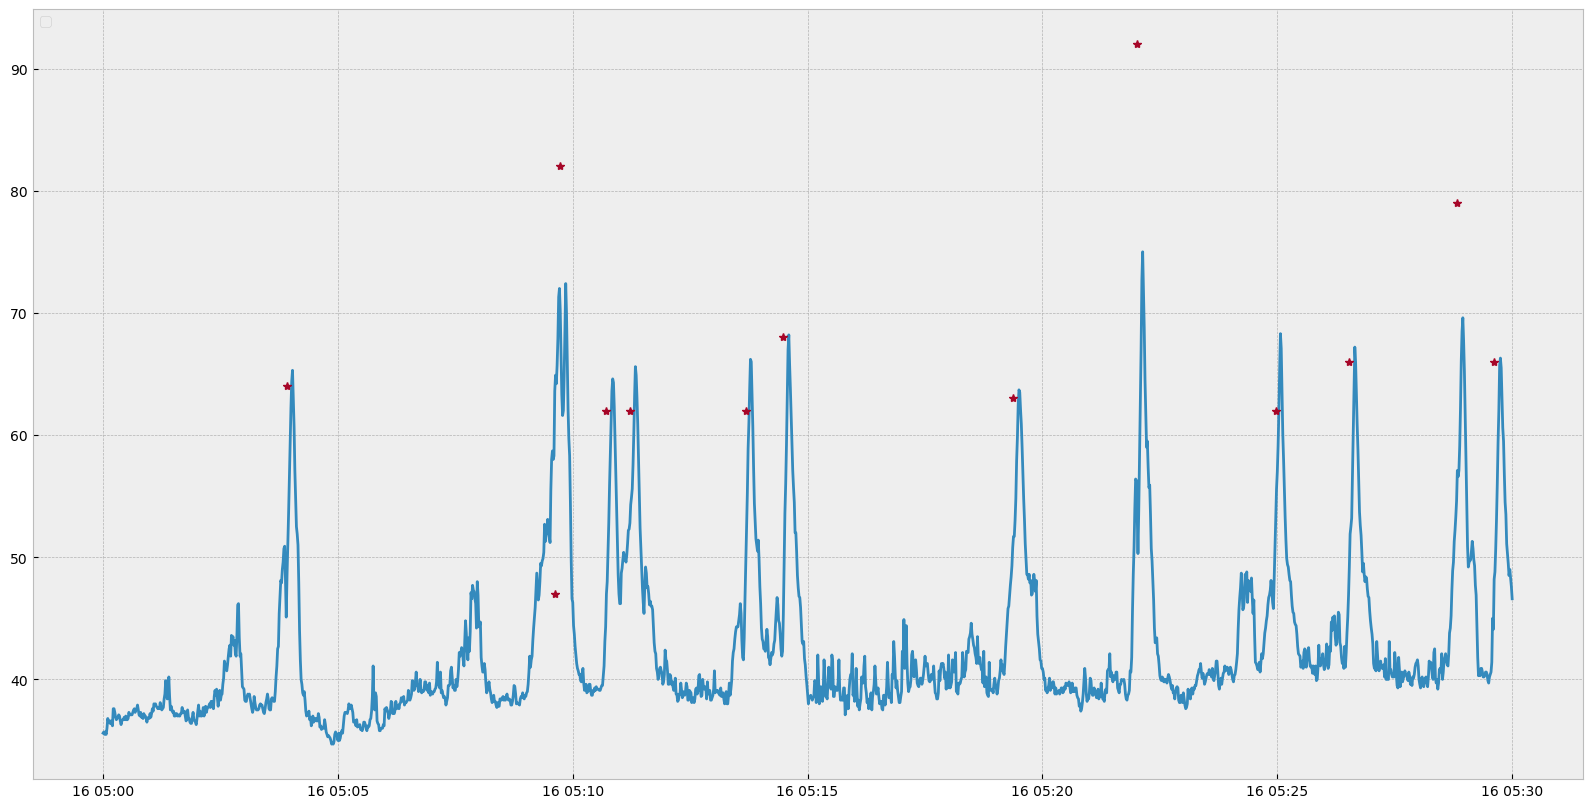

In [16]:
df_temp = df_join.loc["2023-06-16 05:00:00": "2023-06-16 05:30:00"]

levels = df_temp["LAeq"].values

# make log 10 of all speed values
speed = df_temp["Speed"].values
speed_log_scaled = 10 * np.log10(speed + 1)

plt.figure(figsize=(20,10))

# adding a legend for the speed on the left side
plt.legend(["LAeq", "Speed"], loc="upper left")

# plotting the speed values according to the speed y axies


plt.plot(df_temp.index, levels);
plt.plot(df_temp.index, speed + 15, "*");

# 1.1 Selección de pass bys
Se seleccionan aquellas detecciones que tiene un espacio mayor a 10 segundos con la detección
anteior y la siguiente

In [21]:
df_car_detections = df_join[~df_join["Speed"].isna()].copy()
df_car_detections["left"] = df_car_detections["datetime"].shift()
df_car_detections["right"] = df_car_detections["datetime"].shift(-1)
df_car_detections["diff_left"] = df_car_detections["datetime"] - df_car_detections["left"]
df_car_detections["diff_right"] = df_car_detections["right"] - df_car_detections["datetime"]

# Select clean pass bys
df_clean_pass_by = df_car_detections[ (df_car_detections["diff_left"] > "10s") & (df_car_detections["diff_right"] > "10s") ].copy()

Usando estas detecciones se calcula el nivel exposición sonora con los datos de ruido y se grafican
los niveles para comprpbar que corresponden con las formas de onda tipicas de pass by. Se puede
observar que la mayoria siguen en este patrón aunque existen otras tantas que difieren del patrón
tipico de pass-by

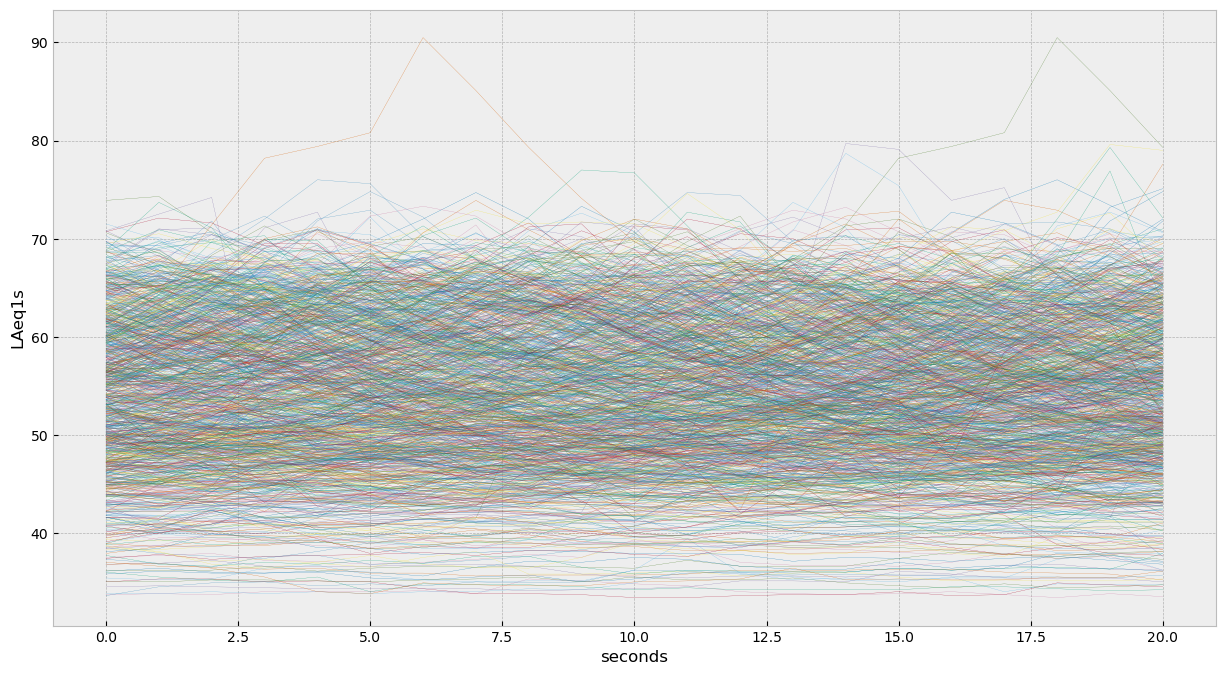

In [22]:
pass_by_width_seconds = 10
sel_pass = []
i = 0
plt.figure(figsize=(15,8))
for date_paso, pass_by in df_clean_pass_by.iterrows():

    df_temp = df_join.loc[date_paso - pd.Timedelta(f"{pass_by_width_seconds}s"):
    date_paso + pd.Timedelta(f"{pass_by_width_seconds}s") ]
    levels = df_temp["LAeq"]
    sel_pass.append(leq(levels) + np.log(8))
    plt.plot(levels.values, linewidth=0.15)
    #i+=1
    if i == 5:
        break

plt.xlabel("seconds")
plt.ylabel("LAeq1s")
plt.show()
df_clean_pass_by["SEL"] = sel_pass

Finalmente se puede observar la relación entre velocidad y SEL de los datos recogidos con el pass
by automático

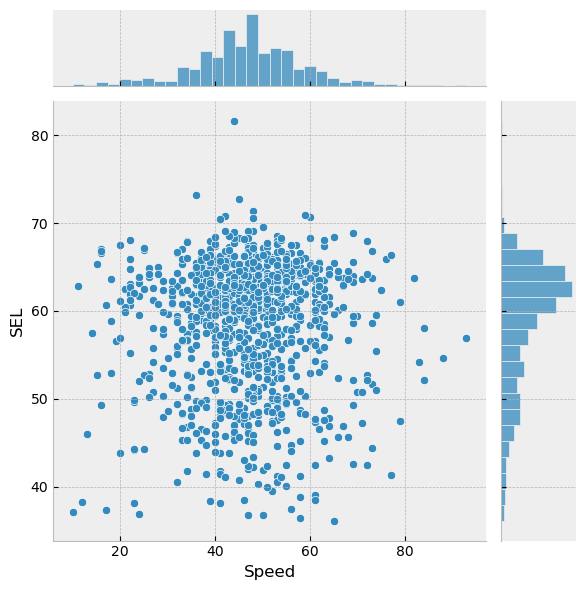

In [23]:
sns.jointplot(data=df_clean_pass_by, x="Speed", y = "SEL",);